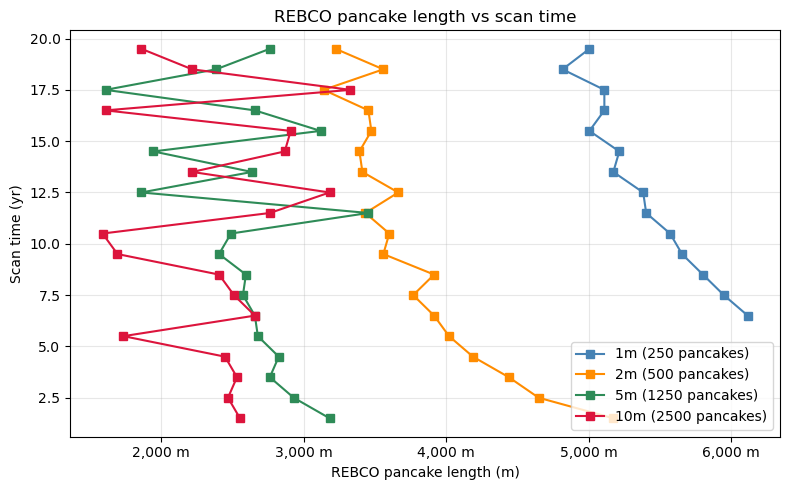

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

files = {
    '1m' : ('area_grids_L1000mm.csv',   250),
    '2m' : ('area_grids_L2000mm.csv',   500),
    '5m' : ('area_grids_L5000mm.csv',  1250),
    '10m': ('area_grids_L10000mm.csv', 2500),
}

colors = {
    '1m' : 'steelblue',
    '2m' : 'darkorange',
    '5m' : 'seagreen',
    '10m': 'crimson',
}

fig, ax = plt.subplots(figsize=(8, 5))

for label, (fname, n_pancakes) in files.items():
    df = pd.read_csv(fname)
    df.columns = df.columns.str.strip()
    df = df[df['converged'].astype(str).str.strip() == 'True'].copy()
    df = df[(df['scan'] >= 1) & (df['scan'] <= 20)].copy()

    bin_edges = np.arange(1, 21, 1)
    df['scan_bin'] = pd.cut(df['scan'], bins=bin_edges, labels=np.arange(1, 20), right=False)
    df = df.dropna(subset=['scan_bin']).copy()
    df['scan_bin'] = df['scan_bin'].astype(int)

    results = (df.groupby('scan_bin')['rebco_pancake_length']
                 .quantile(0.60)
                 .reset_index()
                 .rename(columns={'rebco_pancake_length': 'p60'}))
    results['scan_yr_mid'] = results['scan_bin'] + 0.5

    ax.plot(results['p60'], results['scan_yr_mid'], color=colors[label], marker='s',
            linewidth=1.5, label=f'{label} ({n_pancakes} pancakes)')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f} m'))
ax.set_xlabel('REBCO pancake length (m)')
ax.set_ylabel('Scan time (yr)')
ax.set_title('REBCO pancake length vs scan time')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scan_vs_pancake_90pct.png', dpi=150, bbox_inches='tight')
plt.show()

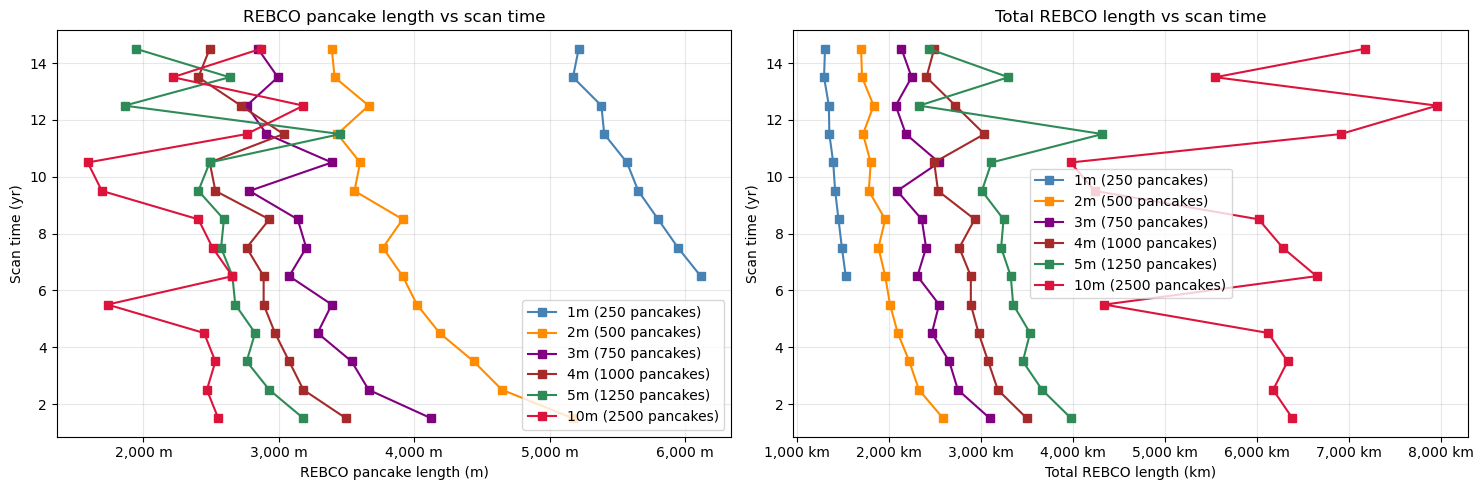

Saved → magnet_characteristics.csv


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

LENGTHS_M   = [1.0, 2.0, 3.0, 4.0, 5.0, 10.0]
THICKNESS_M = 0.004

files = {
    f'{l:g}m': (f'area_grids_L{int(l*1000)}mm.csv', int(l / THICKNESS_M))
    for l in LENGTHS_M
}

colors = {
    '1m' : 'steelblue',
    '2m' : 'darkorange',
    '3m' : 'purple',
    '4m' : 'brown',
    '5m' : 'seagreen',
    '10m': 'crimson',
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

all_results = {}

for label, (fname, n_pancakes) in files.items():
    try:
        df = pd.read_csv(fname)
    except FileNotFoundError:
        print(f'  [!] File not found: {fname}')
        continue

    df.columns = df.columns.str.strip()
    df = df[df['converged'].astype(str).str.strip() == 'True'].copy()
    df = df[(df['scan'] >= 1) & (df['scan'] <= 15)].copy()

    bin_edges = np.arange(1, 16, 1)
    df['scan_bin'] = pd.cut(df['scan'], bins=bin_edges, labels=np.arange(1, 15), right=False)
    df = df.dropna(subset=['scan_bin']).copy()
    df['scan_bin'] = df['scan_bin'].astype(int)

    results = (df.groupby('scan_bin')['rebco_pancake_length']
                 .quantile(0.60)
                 .reset_index()
                 .rename(columns={'rebco_pancake_length': 'p60'}))
    results['scan_yr_mid']    = results['scan_bin'] + 0.5
    results['rebco_total_km'] = results['p60'] * n_pancakes / 1000

    all_results[label] = results

    c = colors[label]
    ax1.plot(results['p60'], results['scan_yr_mid'], color=c, marker='s',
             linewidth=1.5, label=f'{label} ({n_pancakes} pancakes)')
    ax2.plot(results['rebco_total_km'], results['scan_yr_mid'], color=c, marker='s',
             linewidth=1.5, label=f'{label} ({n_pancakes} pancakes)')

# ── Third plot: single vs double volume for all lengths ───────────────────────
#for label, results in all_results.items():
#    c = colors[label]

#     double = results.copy()
#     double['rebco_total_km'] = results['rebco_total_km'] * 2
#     double['scan_yr_mid']    = results['scan_yr_mid']    / 2

#     sqrt2 = results.copy()
#     sqrt2['rebco_total_km'] = results['rebco_total_km'] * 2
#     sqrt2['scan_yr_mid']    = results['scan_yr_mid']    / np.sqrt(2)

#     ax3.plot(results['rebco_total_km'], results['scan_yr_mid'],
#              color=c, marker='s', linewidth=1.5,
#              label=f'{label} — single')
#     ax3.plot(double['rebco_total_km'], double['scan_yr_mid'],
#              color=c, linewidth=1.5, linestyle='--',
#              label=f'{label} — 2× REBCO, ½ scan rate')
#     ax3.plot(sqrt2['rebco_total_km'], sqrt2['scan_yr_mid'],
#              color=c, linewidth=1.5, linestyle=':',
#              label=r'%s — 2× REBCO, $1/\sqrt{2}$ scan rate' % label)

ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f} m'))
ax1.set_xlabel('REBCO pancake length (m)')
ax1.set_ylabel('Scan time (yr)')
ax1.set_title('REBCO pancake length vs scan time')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f} km'))
ax2.set_xlabel('Total REBCO length (km)')
ax2.set_ylabel('Scan time (yr)')
ax2.set_title('Total REBCO length vs scan time')
ax2.legend()
ax2.grid(True, alpha=0.3)

# ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f} km'))
# ax3.set_xlabel('Total REBCO length (km)')
# ax3.set_ylabel('Scan time (yr)')
# ax3.set_title('Single vs double volume (all lengths)')
# ax3.legend(fontsize=7)
# ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scan_vs_pancake_90pct.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save CSV ──────────────────────────────────────────────────────────────────
RAW_COLS = ['row_i', 'col_j', 'solenoid_length_m', 'ri', 'rf', 'th', 'a', 'a_sc',
            'v', 'v_bore', 'b0', 'scan', 'je_sc', 'je_max', 'stress',
            'rebco_pancake_length', 'rebco_total_length', 'j_crit', 'margin', 'converged']

csv_rows = []

for label, (fname, n_pancakes) in files.items():
    if label not in all_results:
        continue

    # reload the raw filtered data for this file
    df_raw = pd.read_csv(fname)
    df_raw.columns = df_raw.columns.str.strip()
    df_raw = df_raw[df_raw['converged'].astype(str).str.strip() == 'True'].copy()
    df_raw = df_raw[(df_raw['scan'] >= 1) & (df_raw['scan'] <= 15)].copy()

    bin_edges = np.arange(1, 16, 1)
    df_raw['scan_bin'] = pd.cut(df_raw['scan'], bins=bin_edges, labels=np.arange(1, 15), right=False)
    df_raw = df_raw.dropna(subset=['scan_bin']).copy()
    df_raw['scan_bin'] = df_raw['scan_bin'].astype(int)

    conductor_length_m = float(label.replace('m', ''))
    results = all_results[label]

    for _, row in results.iterrows():
        bin_group = df_raw[df_raw['scan_bin'] == row['scan_bin']]

        # find the row closest to the p60 pancake length
        idx = (bin_group['rebco_pancake_length'] - row['p60']).abs().idxmin()
        closest = bin_group.loc[idx]

        entry = {
            'conductor_length_m'  : conductor_length_m,
            'n_pancakes'          : n_pancakes,
            'thickness_m'         : THICKNESS_M,
            'scan_bin'            : row['scan_bin'],
            'scan_yr_mid'         : row['scan_yr_mid'],
            'pancake_length_p60_m': row['p60'],
            'rebco_total_km'      : row['rebco_total_km'],
        }

        for col in RAW_COLS:
            if col in closest.index:
                entry[col] = closest[col]

        csv_rows.append(entry)

pd.DataFrame(csv_rows).to_csv('magnet_characteristics.csv', index=False)
print("Saved → magnet_characteristics.csv")